# Circle Packing

This notebook contains a complete example for how to use ShinkaEvolve in a Jupyter notebook environment. It implements a ShinkaEvolve experiment which solves the **Circle Packing Problem**.

**(TASK) Circle Packing Problem** - Pack 26 non-overlapping circles inside the unit square `[0,1]²`  

**(OBJECTIVE) Circle Packing Problem** - Maximize the **sum of radii** (best known ≈ 2.635 for n=26)

The code in this notebook is split into **five sections**.

1.  A pre-flight check that verifies **ShinkaEvolve imports properly**, and that an **OpenRouter API key** is present in your project.

2.  Configures a ShinkaEvolve experiment for Circle Packing

3.  Launches the ShinkaEvolve experiment using `ShinkaEvolveRunner`

4.  Visualizes the experiment's evolution using the WebUI through `shinka_visualize`.

5.  Explores the output of the experiment by plotting the score vs. generation of the evolution, and a visualization of the best packing found by ShinkaEvolve.

Before beginning **make sure you have the following**

- If you are using Jupyterlab to edit this notebook in your web browser, make sure you've started your Jupyter server in the virtual environment

- If you are editing this notebook in VSCode, make sure to select the Python kernel associated with the environment that you've created. It should say `tutorial_shinka (<version>)` with a Python executable located at `.venv/bin/python`.

- You can more-detailed instructions on how to do this in `recipes/shinka_via_jupyter.md`

---

# Part 1. Pre-flight Check

Before we begin, let's verify that our programming environment is set up correctly. This notebook should be running via a JupyterLab server executed in a virtual environment. The following block of code will do two things.

1.  Check that your virtual environment has the Python ShinkaEvolve package `shinka` installed.

2.  Load the **OpenRouter API key** into the Jupyter notebook.

**Important (!)** - Make sure that your OpenRouter API key is contained a `.env` file located at the root of this project, i.e. immediately inside the `tutorial_shinka/` directory.

In [ ]:
import warnings
import dotenv
import os

# Suppress third-party warnings before importing shinka
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

# Check if ShinkaEvolve is importable
try:
    import shinka
except ImportError:
    print("shinka not found, make sure to open this notebook with the ShinkaEvolve environment active")

# Find the .env file
env_path = dotenv.find_dotenv()

# Make sure that there's a .env file
assert env_path, ".env not found, please add it to the root of this project."

# Find the repository root assuming that's where the .env file is
repo_path = os.path.dirname(env_path)
activate_path = os.path.join(repo_path, '.venv/bin/activate')

# Print out where the .env file and repo root are
print("> loaded .env from {}".format(env_path))
print("> repo root located at {}".format(repo_path))

# Load the environment variables
dotenv.load_dotenv()

# Check that OPENROUTER_API_KEY is set in the .env file
if os.environ.get("OPENROUTER_API_KEY"):
    print("> OPENROUTER_API_KEY found")
else:
    print("> WARNING: OPENROUTER_API_KEY not set — add it to .env file")

> loaded .env from /Users/antares/Documents/research/programming/Tutorial_Shinka/.env
> repo root located at /Users/antares/Documents/research/programming/Tutorial_Shinka
> OPENROUTER_API_KEY found


We can verify that `evaluate.py` runs correctly on `initial_program.py` before launching evolution.

In [5]:
import evaluate
import initial_program

# Test the initial program for circle packing
output = initial_program.run_packing()

# Check if the the program outputs a valid circle packing
valid, msg = evaluate.validate_packing(output)

# Assert check
assert valid, f"> Initial test FAILED: {msg}"

print(f"> Initial test: PASSED  (sum_radii={output[2]:.6f})")

> Initial test: PASSED  (sum_radii=1.821228)


We're ready to go!

# Part 2. Configuring the ShinkaEvolve Experiment

There are a number of hyperparameters that one can use to configure a ShinkaEvolve experiment. There are three Python objects which collect all possible parameters that can be used to configure a ShinkaEvolve experiment.

-   `EvolutionConfig`

-   `DatabaseConfig`

-   `LocalJobConfig`

The **bare minimum** collection of parameters that the user needs to define in order to run an experiment are the following.

-   `init_program_path` in `EvolutionConfig` - This parameter tells ShinkaEvolve where your **initial program** is. The initial program is the first program to be added to the population, and will be used to evolve subsequent programs.

-   `eval_program_path` in `LocalJobConfig` - This parameter tells ShinkaEvolve where your **evaluation code**. The evaluation code contains all code **outside the context of an LLM** that you write for (1) validating that generated programs are correct, and (2) evaluating the score of the program.

Let's first define these parameters as global variables.

In [18]:
# Path to the initial program
INIT_PROGRAM_PATH = "initial_program.py"

# Path to evaluate.py
EVAL_PROGRAM_PATH = "evaluate.py"

In practice, there are a number of other parameters in which setting them will lead to qualitative improvements on the output of your experiment. We'll list some of these parameters here.

-   `EvolutionConfig.task_sys_msg` - Problem context given to every mutation LLM. The **single most impactful parameter**; includes domain knowledge, constraints, and directions to explore.

-   `EvolutionConfig.num_generations` - How many evolutionary generations to run. Start with 10–20 to sanity-check, scale up for serious runs.

-   `EvolutionConfig.results_dir` - Where databases and the best program are saved.

Let's define these as global variables as well.

In [19]:
import datetime as dt

# A description of the task ShinkaEvolve is solving to be sent as an LLM prompt.
TASK_SYS_MSG = """
You are an expert mathematician specialising in circle packing and computational geometry.
The best known result for the sum of radii when packing 26 circles in a unit square is 2.635.

Key directions to explore:
1. Variable-sized circles — the optimal packing uses circles of different radii.
2. Corner and edge placement — small circles fit efficiently near walls.
3. Hexagonal-grid initialisation combined with local optimisation (e.g. scipy L-BFGS-B / SLSQP).
4. Joint optimisation of centre positions AND radii as a single NLP.
5. Simulated annealing or basin-hopping for global search.
6. Greedy algorithms: place circles one at a time maximising contribution to sum.
7. Literature-inspired layouts for specific n (e.g. Packomania database).

Constraints:
- construct_packing() must return (centers, radii) with centers.shape=(26,2) and radii.shape=(26,).
- run_packing() (the fixed interface) calls construct_packing() and returns (centers, radii, sum_radii).
- All circles must lie strictly inside [0,1]^2 and must not overlap.
- HIGHER sum of radii = BETTER score.

Be creative. Try to beat 2.635."""

# Number of generations to run in this experiment
NUM_GENERATIONS = 10

# Results will be stored in a directory "circpack_<CURRENT DATE-TIME>"
experiment_name = "circpack_" + dt.datetime.now().strftime("%Y%m%d_%H%M%S")

# Set RESULTS_DIR
RESULTS_DIR = "results/{}".format(experiment_name)

# Print out the path
print(f"> Results dir: {RESULTS_DIR}")

> Results dir: results/circpack_20260420_192217


Another parameter that we'll call out involves **how to manage API costs** during a run of ShinkaEvolve.

-   `EvolutionConfig.max_api_cost` - The run stops when the cost accumulated across *all API calls* reaches this value. Set it to avoid surprise bills during long runs!

In [20]:
# Set cost if you want to try this out!
cost = 0

# Define the MAX_API_COST variable
MAX_API_COST = cost or None

# Has my cost been set?
print('> Cost limit? {}'.format(MAX_API_COST))

> Cost limit? None


Because we are using **OpenRouter** we'll need to set any parameter which involves deciding what LLM is used for which part of the system. The parameters that relate to choosing an LLM model are the following.

-   `EvolutionConfig.llm_models`

-   `EvolutionConfig.meta_llm_models`

-   `EvolutionConfig.novelty_llm_models`

-   `EvolutionConfig.embedding_model`

This is because the default values for these parameters in OpenAI specific models.

In [21]:
# Define all LLM related hyperparameters.
LLM_MODELS = [
    "openrouter/anthropic/claude-haiku-4-5",
    "openrouter/openai/gpt-5.1-codex-mini",
    "openrouter/openai/gpt-5-nano",
    "openrouter/google/gemini-3-flash-preview"
]

META_LLM_MODELS = ["openrouter/openai/o4-mini"]

NOVELTY_LLM_MODELS = ["openrouter/openai/o4-mini"]

EMBEDDING_MODEL = "openrouter/openai/text-embedding-3-small"

For a more complete list of hyperparameters, and what they do see the guide in `recipes/hyperparameters.md`. Now, here's the code which will create the `*Config` objects with all the parameters we've just set.

In [ ]:
# Import from config objects from the shinka library
from shinka.core import EvolutionConfig
from shinka.database import DatabaseConfig
from shinka.launch import LocalJobConfig


# Set the evolution config object
evo_config = EvolutionConfig(init_program_path=INIT_PROGRAM_PATH,
                             task_sys_msg=TASK_SYS_MSG,
                             num_generations=NUM_GENERATIONS,
                             results_dir=RESULTS_DIR,
                             max_api_costs=MAX_API_COST,
                             llm_models=LLM_MODELS,
                             meta_llm_models=META_LLM_MODELS,
                             novelty_llm_models=NOVELTY_LLM_MODELS,
                             embedding_model=EMBEDDING_MODEL)


# Set the job config. ACTIVATE_SCRIPT is a parameter which tells what virtual
# environment ShinkaEvolve will run evolved programs in.
job_config = LocalJobConfig(eval_program_path=EVAL_PROGRAM_PATH,
                            activate_script=activate_path)

# If you're using Conda to manage your virtual environment, you will need to
# instead set CONDA_ENV. Uncomment this line to do that
# job_config = LocalJobConfig(eval_program_path=EVAL_PROGRAM_PATH,
#                             conda_env="shinka_ai4sd26")

# Number of islands is a hyperparameter which affects the evolution algorithm
# run by ShinkaEvolve. This also affects the visualization. See the guide
# at `recipes/hyperparameters.md` for more information.
db_config = DatabaseConfig(num_islands=2)

# Part 3. Launch ShinkaEvolve

Now we're ready to launch ShinkaEvolve. Pass all config parameters (the `EvolutionConfig, DatabaseConfig, LocalJobConfig` objects) to a `ShinkaEvolveRunner` object. Then call `run_async` to start the evolving.

**IMPORTANT (!)** - Running the next block will output a lot of text! You can continue on to **Part 4** as this block runs. **Part 5** will need to wait until this block finishes.

In [23]:
from shinka.core import ShinkaEvolveRunner

from time import perf_counter

# Create the ShinkaEvolveRunner object.
runner = ShinkaEvolveRunner(
    evo_config=evo_config,
    job_config=job_config,
    db_config=db_config,
    verbose=True,
)

# Store the starting wallclock time
tic = perf_counter()

# Run ShinkaEvolve by calling `run_async`
await runner.run_async()

# Store the stop wallclock time
toc = perf_counter()

# Print out information
print(f"> Evolution completed in {toc - tic:.1f} s")
print(f"> Results saved to: {runner.results_dir}")

  @@@@@@@@@@@@@@@@@@@@@      ░██████╗██╗░░██╗██╗███╗░░██╗██╗░░██╗░█████╗░
  @                   @      ██╔════╝██║░░██║██║████╗░██║██║░██╔╝██╔══██╗
  @          @        @      ╚█████╗░███████║██║██╔██╗██║█████═╝░███████║
  @    @@   @@  @@    @      ░╚═══██╗██╔══██║██║██║╚████║██╔═██╗░██╔══██║
  @   @     @    @@   @      ██████╔╝██║░░██║██║██║░╚███║██║░╚██╗██║░░██║
  @    @@  @    @     @      ╚═════╝░╚═╝░░╚═╝╚═╝╚═╝░░╚══╝╚═╝░░╚═╝╚═╝░░╚═╝
  @        @          @      @@@@@@@@@@@@@@@
  @                   @   @@                 @@@@@
  @@@@@@@@@@@@@@@@@@@@ @@                       @  @@                 █▀▀
                      @                          @@  @                ██▄
                    @      @@                      @  @@
                   @       @         @              @   @             █░█
                   @                 @               @  @             ▀▄▀
                     @@@@@          @     @           @  @
                      @            @          @ 

2026-04-20 19:26:03 - shinka.core.async_runner - INFO - 🖥️  System resources detected:

2026-04-20 19:26:03 - shinka.core.async_runner - INFO -    • CPU cores: 16

2026-04-20 19:26:03 - shinka.core.async_runner - INFO -    • Memory: 48.0 GB

2026-04-20 19:26:03 - shinka.core.async_runner - INFO - 🔧 Concurrency settings:

...

2026-04-20 19:33:11 - shinka.llm.llm - INFO - ==> QUERYING: ['openrouter/openai/gpt-5-nano', '0.0', '16384']

2026-04-20 19:33:12 - httpx - INFO - HTTP Request: POST https://openrouter.ai/api/v1/responses "HTTP/1.1 200 OK"

2026-04-20 19:33:51 - shinka.database.async_dbase - INFO - 🔧 Closing async database with monitoring...

2026-04-20 19:33:51 - shinka.database.async_dbase - INFO - Async database closed

CancelledError: 

# Part 4. Visualizing ShinkaEvolve using the WebUI

By default, logging information when running ShinkaEvolve will be sent to the environment you're running your code in (Jupyterlab or the terminal). This text can be hard to parse, and so the ShinkaEvolve package also contains a **visualization tool** that has a **web user interface**. 

You can launch this tool through the command line by following these steps.

1.  Open a separate terminal, navigate to the directory containing this repository `tutorial_shinka`.

2.  Activate the virtual environment.

3.  Run the following command inside the repository

    ```bash
    shinka_visualize --db results --port 8000 --open
    ```

This will open the WebUI with a lot of information about the evolution.

**IMPORTANT (!)** - There may be a bug when launching the Web UI, where the browser tab opens but the database is not loaded. To resolve it, click on `Dashboard` on the top left corner and the list of available databases should appear.

# Part 5. Exploring the results of running ShinkaEvolve

Once your ShinkaEvolve experiment has finishes, we can explore its output using other Python libraries.

The following code will create two plots.

-   The left plot will contains curves as a function of number of programs evaluated by ShinkaEvolve: best score, and cumulative cost.

-   The right plot will visualize the lineage tree between programs generated during your run.

Total program rows: 9
Correct program rows: 7
Total cost: $0.09
Avg cost per program: $0.01
> Loaded 9 programs from database.
GraphViz not available, using hierarchical layout


/Users/antares/Documents/research/programming/Tutorial_Shinka/.venv/lib/python3.13/site-packages/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/antares/Documents/research/programming/Tutorial_Shinka/.venv/lib/python3.13/site-packages/shinka/plots/plot_lineage_tree.py:398: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/antares/Documents/research/programming/Tutorial_Shinka/.venv/lib/python3.13/site-packages/networkx/draw

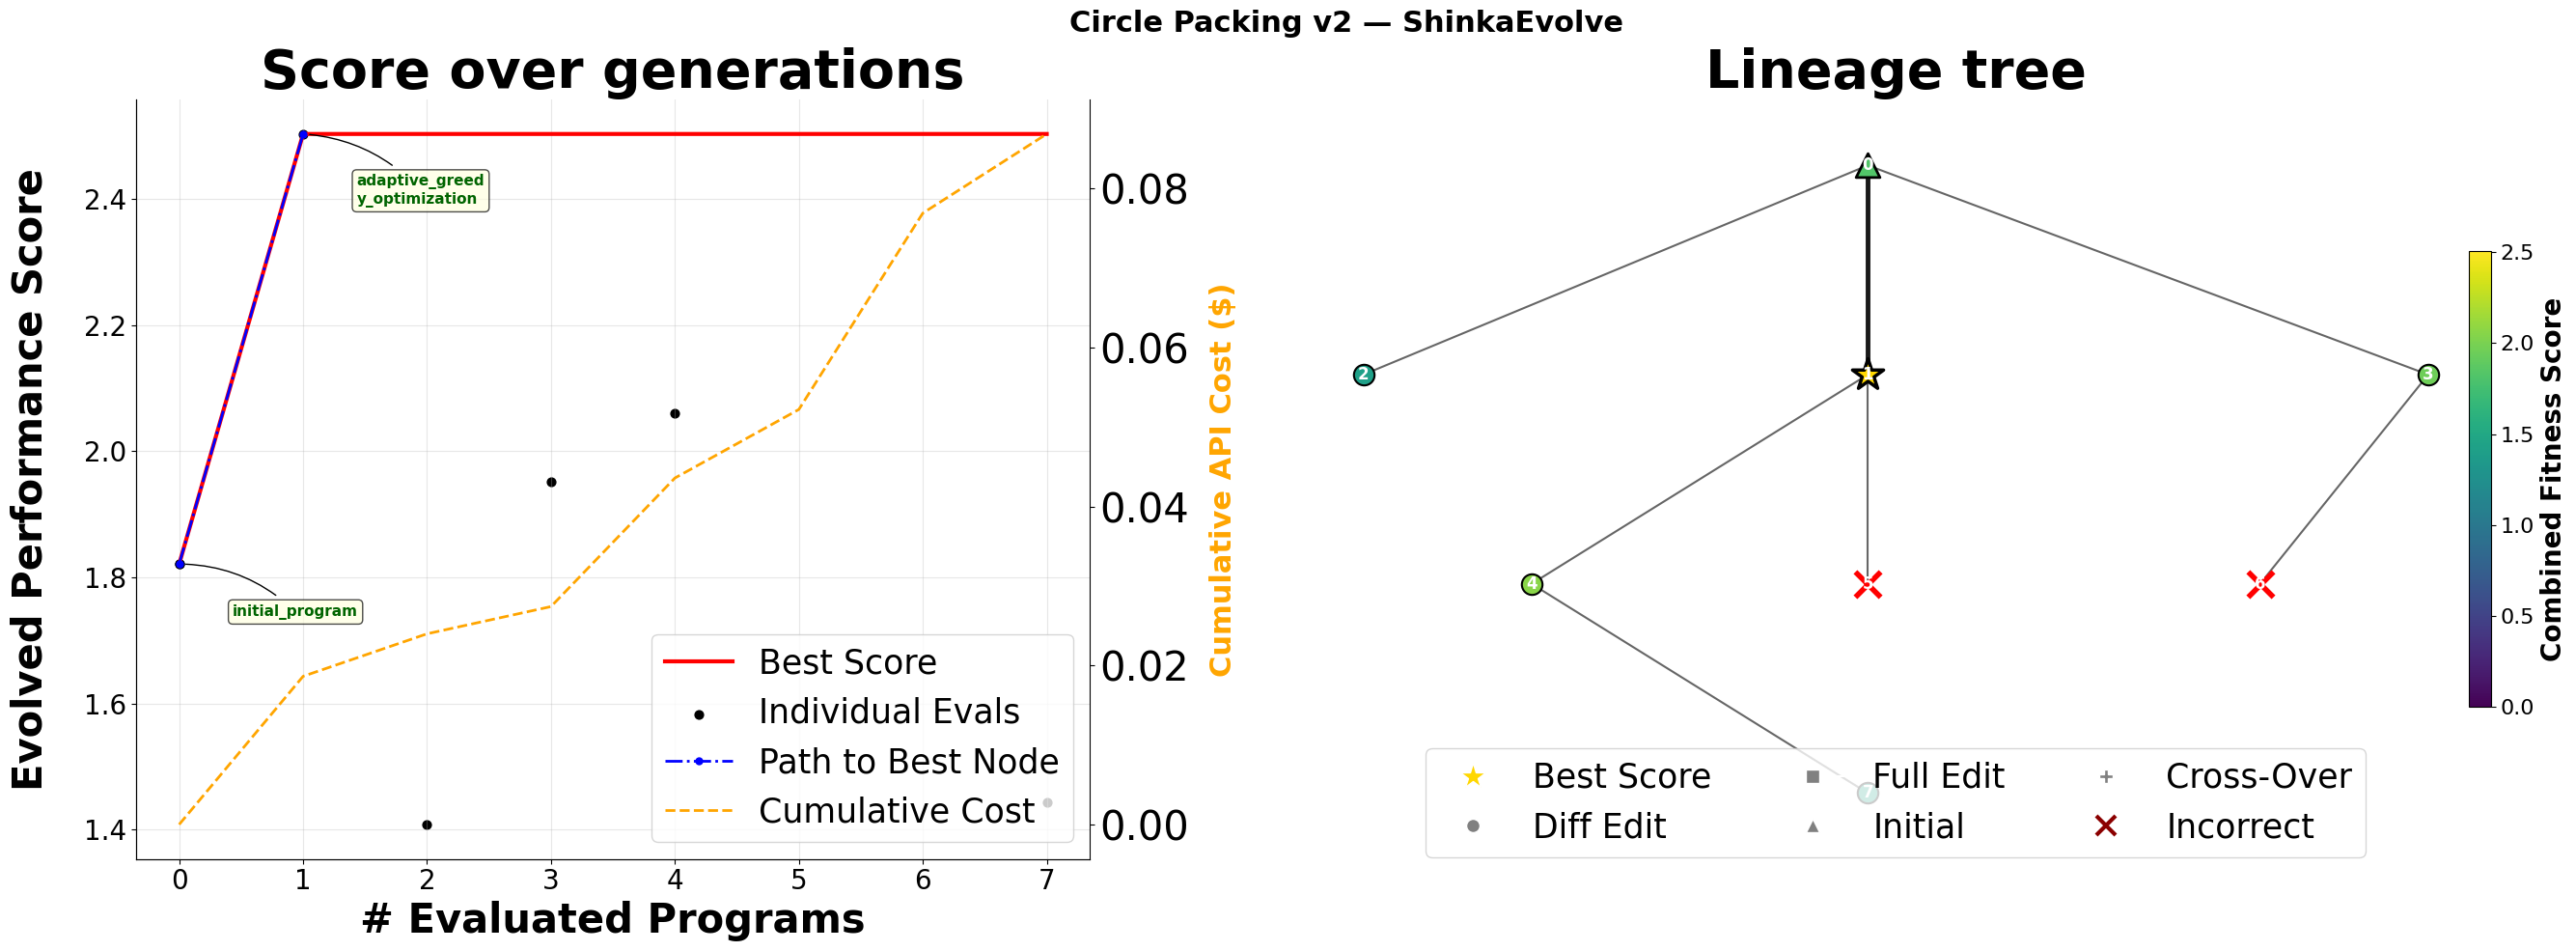

In [28]:
import matplotlib.pyplot as plt

from pathlib import Path

from shinka.utils import load_programs_to_df
from shinka.plots import plot_lineage_tree, plot_evals_performance


results_root = Path("results") / experiment_name

# The db may sit directly in results_root or one level up (shinka convention)
db_candidates = [
    results_root / "programs.sqlite"
    # results_root / results_root / "evolution_db.sqlite",
    # Path("evolution_db.sqlite"),
]

db_path = next((p for p in db_candidates if p.exists()), None)

assert db_path is not None, "Could not find evolution_db.sqlite"

df = load_programs_to_df(str(db_path))

print(f"> Loaded {len(df)} programs from database.")

fig, axs = plt.subplots(1, 2, figsize=(28, 10), gridspec_kw={"width_ratios": [1, 1.5]})
fig.suptitle("Circle Packing v2 — ShinkaEvolve", fontsize=22, weight="bold")

plot_evals_performance(df, "Score over generations", fig, axs[0])
plot_lineage_tree(df, "Lineage tree", fig, axs[1])

plt.tight_layout()
plt.show()

The following block of code will output the **sum of radii** for the best packing found during your run.

It will also output the **minimum** and **maximum radius** of any one circle in the best packing.

In [30]:
import importlib.util
import numpy as np

best_program = results_root / "best" / "main.py"
assert best_program.exists(), f"Best program not found at {best_program}"

spec = importlib.util.spec_from_file_location("best_program", best_program)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

centers, radii, sum_radii = mod.run_packing()

print(f"> Sum of radii (best): {sum_radii:.6f}  (target: 2.635)")
print(f"> Min radius: {radii.min():.4f}")
print(f"> Max radius: {radii.max():.4f}")

> Sum of radii (best): 2.503053  (target: 2.635)
> Min radius: 0.0239
> Max radius: 0.1635


This block of code will visualize the best packing itself

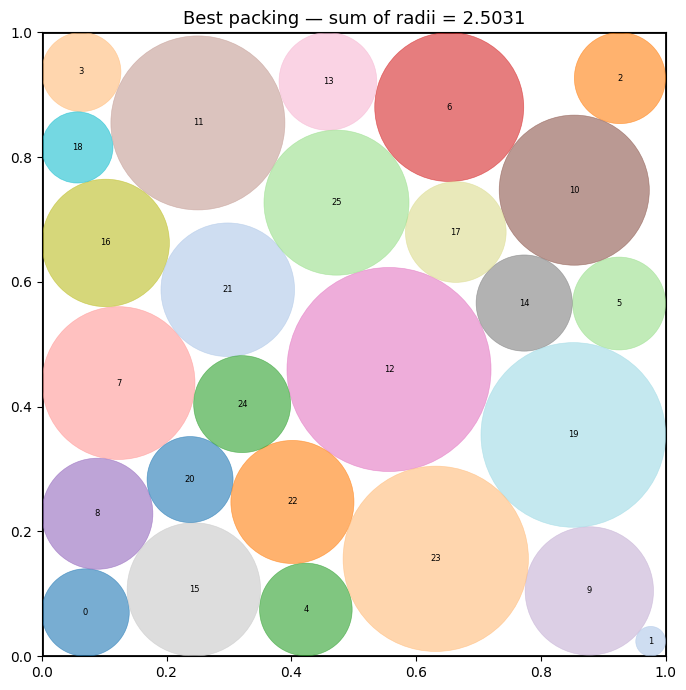

In [31]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_title(f"Best packing — sum of radii = {sum_radii:.4f}", fontsize=13)
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor="black", lw=2))

cmap = plt.cm.tab20
for i, ((x, y), r) in enumerate(zip(centers, radii)):
    circ = plt.Circle((x, y), r, color=cmap(i % 20), alpha=0.6, linewidth=0.5, edgecolor="black")
    ax.add_patch(circ)
    ax.text(x, y, str(i), ha="center", va="center", fontsize=6)

plt.tight_layout()
plt.show()

# Where to go from here?

In this notebook, we ran through an end-to-end example of using ShinkaEvolve to solve a search problem: **Circle Packing**. The way we interfaced with ShinkaEvolve was through this Jupyter notebook. You now have all the tools necessary to explore more advanced features of ShinkaEvolve.

-   Identify a search problem in your own research and try applying ShinkaEvolve. For more inspiration see the other notebooks in this repository.

-   Check out some of the guides for using ShinkaEvolve in more complex ways. See `recipes/shinka_via_script.md`.